# Exercises XP: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition and transfer to other AI topics.



## Reference from the exercise

**What you will learn**  
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**  
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.


## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

**As stated in the exercise**  
Objective. Understand the differences between traditional machine learning and deep learning.  
Instructions. Create a table comparing Feature Engineering, Data Processing, Scalability, Pattern Discovery, and Computational Requirements. Identify one real world problem where traditional ML is better, and one where deep learning is better. Write a short paragraph explaining why deep learning has an advantage in unstructured data processing.

**Guidance**  
Use a markdown table for the comparison, keep wording concise and concrete, then write two short examples and one paragraph in full sentences.

**To-Do:** Complete the comparison table below by filling in each cell with your own wording.


| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | Manual — domain experts must design and select features before training | Automatic — the network learns relevant features directly from raw data |
| Data Processing | Works well on small-to-medium structured/tabular datasets | Requires large volumes of data to learn meaningful representations |
| Scalability | Performance plateaus as data grows beyond a certain point | Performance keeps improving with more data and compute |
| Pattern Discovery | Finds shallow, human-interpretable patterns within engineered features | Discovers complex hierarchical patterns (edges → shapes → objects) automatically |
| Computational Requirements | Runs efficiently on CPU; modest memory requirements | Requires GPUs/TPUs and significant memory; training can take hours to weeks |

**To-Do:** Give one real world problem better suited to traditional ML and one better suited to deep learning. Explain your choices in 2–3 sentences.

Real-world problem comparisons:
Traditional ML is better suited to credit scoring (predicting loan default from structured financial records). The dataset is tabular, relatively small, features like income and debt ratio are easily engineered, and interpretability is legally required. A gradient-boosted tree model is both accurate and explainable here.
Deep learning is better suited to medical image diagnosis (e.g. detecting tumours in MRI scans). The input is raw pixel data with no obvious hand-crafted features, the spatial relationships between pixels matter, and CNNs automatically learn hierarchical visual patterns that would be impossible to engineer manually.


**To-Do:** Write a paragraph of 3–5 sentences explaining why deep learning has an advantage in unstructured data processing, using precise terms such as representation learning and hierarchical features.

Paragraph on unstructured data:
Deep learning has a fundamental advantage on unstructured data because of representation learning: rather than relying on a human to decide which features matter, a deep network learns its own internal representations layer by layer. In image recognition, early layers detect low-level features such as edges and colour gradients, intermediate layers combine these into textures and shapes, and deeper layers assemble hierarchical features that correspond to high-level concepts like faces or objects. This hierarchy mirrors the structure of the data itself. Traditional ML cannot build such representations automatically — hand-crafted features for images or audio are both time-consuming and inevitably incomplete — so deep learning consistently outperforms traditional approaches whenever the raw signal is high-dimensional and the useful patterns are complex and nested.


## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective. Identify and understand the key components of an ANN.  
Instructions. Draw or use a diagram tool to create an ANN with an input layer of 3 neurons, one hidden layer of 4 neurons, and an output layer of 2 neurons. Label neurons, weights, biases, activation function, and layers. Write a short description of how information flows through the network.

**Guidance**  
A clear schematic is preferred. Ensure every requested label appears exactly once and is readable.



**To-Do:** Provide a 3–5 sentence description of forward propagation in your diagram. Refer explicitly to inputs, weighted sums, biases, activation, and outputs.

Forward propagation description:
Each input neuron holds one raw feature value (x₁, x₂, x₃). Moving into the hidden layer, every hidden neuron h_j computes a weighted sum of all inputs — multiplying each x_i by its corresponding weight w_ij and adding them together — then adds a learned bias term b. The result of this affine operation is passed through the ReLU activation function, which simply clips negative values to zero, introducing the nonlinearity that lets the network model curved decision boundaries. The activated hidden values are then propagated to the output layer in exactly the same way, each output neuron ŷ_k computing its own weighted sum. Finally, a Softmax activation converts the raw output scores into a probability distribution over the two classes, so the outputs sum to 1 and can be interpreted as class probabilities.


**Learning point**  
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.


## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [1]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [2]:
# To-Do: generate y with noise using np.random.normal()
# Generate y with noise
y = -x**2 + np.random.normal(0, 0.05, size=x.shape)
print("y shape:", y.shape)

y shape: (20,)


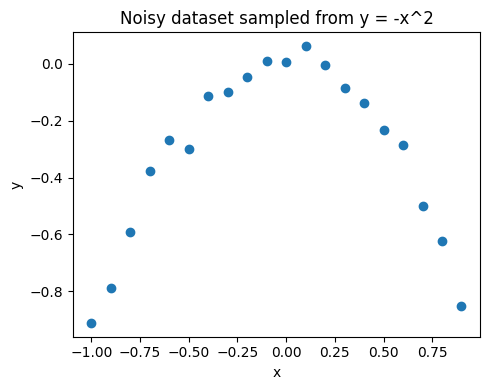

In [3]:
# PREFILLED: just execute (scatter plot of the dataset)
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [4]:
# To-Do: split into train (first 12 points) and test (last 8 points)
# Train/test split
x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]
print("train sizes:", x_train.shape, y_train.shape, "test sizes:", x_test.shape, y_test.shape)

train sizes: (12,) (12,) test sizes: (8,) (8,)


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


In [6]:
# To-Do: implement polynomial_fit
def polynomial_fit(degree: int):
    coeffs = np.polyfit(x_train, y_train, degree)
    return np.poly1d(coeffs)

In [7]:
# To-Do: implement plot_polyfit
def plot_polyfit(degree: int):
    p = polynomial_fit(degree)
    x_line = np.linspace(x.min(), x.max(), 300)
    y_line = p(x_line)

    train_rmse = np.sqrt(mean_squared_error(y_train, p(x_train)))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  p(x_test)))

    plt.figure(figsize=(6, 4))
    plt.scatter(x_train, y_train, color='steelblue', label='Train', zorder=3)
    plt.scatter(x_test,  y_test,  color='tomato',    label='Test',  zorder=3)
    plt.plot(x_line, y_line, color='darkorange', linewidth=2, label=f'Degree {degree}')
    plt.title(f'Polynomial Degree {degree}  |  Train RMSE={train_rmse:.4f}  Test RMSE={test_rmse:.4f}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.tight_layout()
    plt.show()

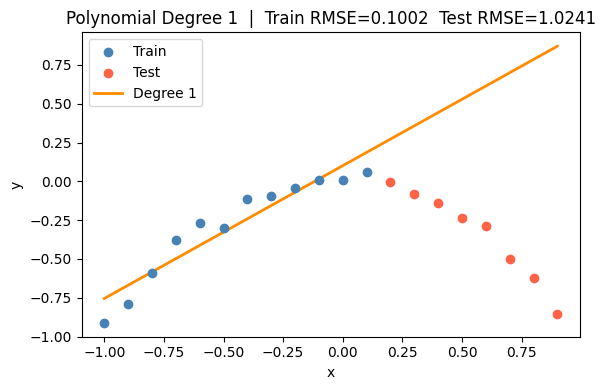

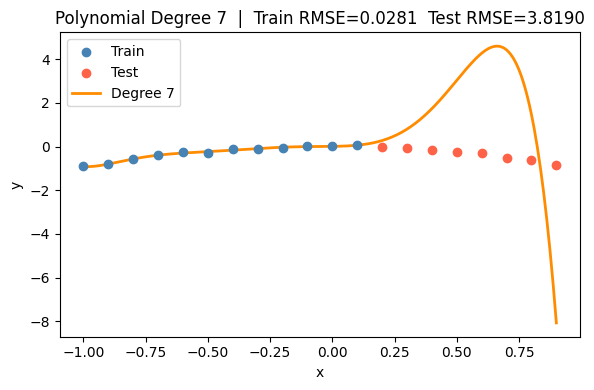

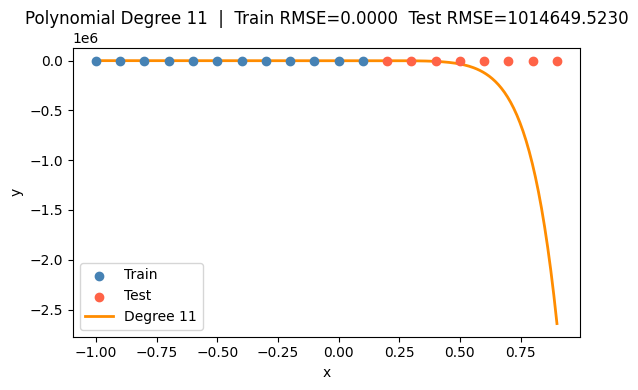

In [9]:
# To-Do: visualize degrees 1, 7, and 11
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)

**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](https://github.com/user-attachments/assets/cdfb495c-066a-4efb-a361-f4b9d4ade35c)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


In [10]:
# To-Do: compute RMSE per degree for train and test
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

degrees = range(1, 12)
rows = []

for d in degrees:
    p = polynomial_fit(d)
    r_train = rmse(y_train, p(x_train))
    r_test  = rmse(y_test,  p(x_test))
    rows.append((d, r_train, r_test))

rows[:3]   # peek


[(1, np.float64(0.1002263344864799), np.float64(1.0240708833556866)),
 (2, np.float64(0.04114590494650985), np.float64(0.12578064282386534)),
 (3, np.float64(0.037336922311085964), np.float64(0.769651993080075))]

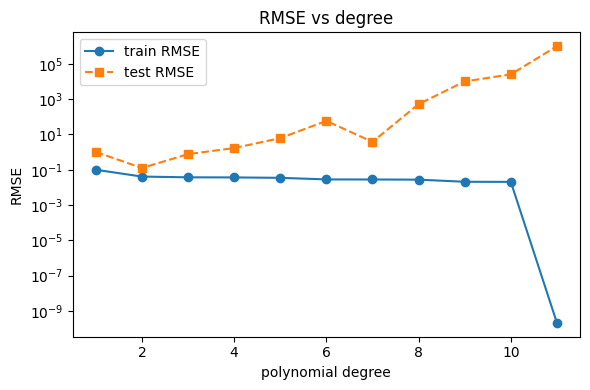

In [12]:
degs    = [r[0] for r in rows]
rmse_tr = [r[1] for r in rows]
rmse_te = [r[2] for r in rows]

plt.figure(figsize=(6, 4))
plt.plot(degs, rmse_tr, label="train RMSE", marker='o')
plt.plot(degs, rmse_te, label="test RMSE",  marker='s', linestyle='--')
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("RMSE")
plt.title("RMSE vs degree")
plt.legend()
plt.tight_layout()
plt.show()


**To-Do:** Report the degree with the minimum test RMSE and explain in 2–3 sentences how this connects to the true model \(y=-x^2\) and the bias–variance trade off.

The minimum test RMSE occurs at degree 2, which corresponds exactly to the true generating model y = −x². This makes intuitive sense through the bias–variance trade-off: a degree-1 polynomial is too rigid (high bias) to capture the parabolic curvature, while degrees 3 and above start absorbing noise as if it were signal (increasing variance), causing test error to rise. At degree 2 the model has just enough flexibility to represent the true function without overfitting to the noise, sitting at the sweet spot where bias and variance are jointly minimised.
